# Real Estate - Feature Analysis

##

In [19]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

BASE_DIR = Path().resolve().parents[0]
file_path = BASE_DIR / "data/processed/dvf_core.parquet"

df = pd.read_parquet(file_path)

In [2]:
print(df.shape)
df.head()

(379890, 38)


,Date mutation,Nature mutation,Valeur fonciere,No voie,Type de voie,Code voie,Voie,Code postal,Commune,Code departement,...,Nombre d'établissements 2024,Effectifs salariés 2024,"École maternelle, primaire, élémentaire (en nombre) 2024",Collège (en nombre) 2024,Lycée (en nombre) 2024,Pharmacie (en nombre) 2024,Médecin généraliste (en nombre) 2024,Taux de chômage trimestriel 2025-T4,Salaire net EQTP mensuel moyen 2023,Taux de pauvreté 2023
0,2025-01-09,Vente,183000.0,250.0,AV,0041,DE BELLE FERME,1170,GEX,01,...,209,2423,6,2,0,3,5,6.4,2364,15.4
1,2025-01-08,Vente,131937.3,62.0,CHE,0950,DU PEUPLE,1330,AMBERIEUX-EN-DOMBES,01,...,49,195,1,0,0,1,1,5.8,2587,6.7
2,2025-01-09,Vente,173000.0,5338.0,,B006,GRAND FAUBOURG,1290,PONT-DE-VEYLE,01,...,51,561,1,1,1,1,4,6.1,2366,7.8
3,2025-01-06,Vente,414665.0,124.0,CHE,0032,DE CHAMP JOURNET,1630,CHALLEX,01,...,11,112,1,0,0,0,0,6.4,2364,15.4
4,2025-01-10,Vente,259000.0,85.0,RUE,0101,DE CHATEAU GAGNEUR,1170,GEX,01,...,209,2423,6,2,0,3,5,6.4,2364,15.4


### Quick checks

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 379890 entries, 0 to 379889
Data columns (total 38 columns):
 #   Column                                                                          Non-Null Count   Dtype         
---  ------                                                                          --------------   -----         
 0   Date mutation                                                                   379890 non-null  datetime64[us]
 1   Nature mutation                                                                 379890 non-null  category      
 2   Valeur fonciere                                                                 379890 non-null  float64       
 3   No voie                                                                         376721 non-null  float64       
 4   Type de voie                                                                    379890 non-null  string        
 5   Code voie                                                                   

In [4]:
df.describe()

,Date mutation,Valeur fonciere,No voie,Code commune,No plan,Code type local,Surface reelle bati,Nombre pieces principales,prix_m2,longitude,...,Nombre d'établissements 2024,Effectifs salariés 2024,"École maternelle, primaire, élémentaire (en nombre) 2024",Collège (en nombre) 2024,Lycée (en nombre) 2024,Pharmacie (en nombre) 2024,Médecin généraliste (en nombre) 2024,Taux de chômage trimestriel 2025-T4,Salaire net EQTP mensuel moyen 2023,Taux de pauvreté 2023
count,379890,3.798900e+05,376721.000000,379890.000000,379890.000000,379890.000000,379890.000000,379890.000000,379890.000000,379890.000000,...,336560.0,336560.0,336560.0,336560.0,336560.0,336560.0,336560.0,336560.0,336540.0,336063.0
mean,2025-07-06 22:06:09.694385,2.275008e+05,446.250501,185.826247,332.787494,2.085388,60.477907,2.450623,3955.016964,2.960181,...,3067.82273,43922.186671,38.017233,7.926206,7.907981,25.735893,87.470264,7.664995,2671.416658,16.672213
min,2025-01-02 00:00:00,2.000000e+03,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1357.142857,-63.077393,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.9,1889.0,4.0
25%,2025-04-09 00:00:00,1.200000e+05,8.000000,61.000000,69.000000,2.000000,37.000000,2.000000,2433.333333,1.502286,...,403.0,3624.0,6.0,1.0,0.0,3.0,10.0,6.7,2343.0,14.0
50%,2025-07-07 00:00:00,1.760000e+05,24.000000,130.000000,178.000000,2.000000,55.000000,2.000000,3442.622951,2.566732,...,1239.0,14011.0,18.0,4.0,3.0,11.0,30.0,7.5,2526.0,17.2
75%,2025-10-01 00:00:00,2.672678e+05,76.000000,264.000000,384.000000,2.000000,73.000000,3.000000,4941.176471,5.374045,...,3974.0,61338.0,46.0,11.0,12.0,33.0,102.0,8.2,2713.0,19.6
max,2025-12-31 00:00:00,6.900000e+07,9999.000000,907.000000,7910.000000,4.000000,21073.000000,89.000000,10250.000000,55.800980,...,19612.0,349860.0,226.0,43.0,47.0,157.0,549.0,14.4,3744.0,33.5
std,NaN,3.239669e+05,1673.800873,163.476030,547.437713,0.569834,78.613610,1.324795,2016.962040,6.978742,...,4391.023664,68178.269007,49.707599,9.982279,11.137471,36.78803,133.816381,1.603232,479.671971,4.28441


### Numerical features

In [26]:
df = df.rename(columns={
    "Médiane du niveau de vie 2023" : "MED_SL",
    "Logements 2022" : "LOG",
    "Nb d'emplois au lieu de travail (LT) 2022" : "NB_EMPLT",
    "Évol. annuelle moy. de la population 2017 - 2023 (en %)" : "EVOL_POP",
    "Évol. annuelle moy. de la pop. due au solde apparent entrées/sorties 2016-2022" : "EVOL_POP_E_S",
    "Unités légales (en nombre) 2023" : "LEGAL_UNIT",
    "Créations d'entreprises (en nombre) 2025" : "LEGAL_UNIT_NEW",
    "Nombre d'établissements 2024" : "UNIT_LOC",
    "Effectifs salariés 2024" : "NB_EMPL",
    "École maternelle, primaire, élémentaire (en nombre) 2024" : "ECOLE",
    "Collège (en nombre) 2024" : "COLLEGE",
    "Lycée (en nombre) 2024" : "LYCEE",
    "Pharmacie (en nombre) 2024" : "PHARMACIE",
    "Médecin généraliste (en nombre) 2024" : "MEDECIN",
    "Taux de chômage trimestriel 2025-T4" : "CHOMAGE",
    "Salaire net EQTP mensuel moyen 2023" : "SL",
    "Taux de pauvreté 2023" : "PR_MD60"
})

features = [
    "Valeur fonciere",
    "Surface reelle bati",
    "Nombre pieces principales",
    "prix_m2",
    "longitude",
    "latitude",
    "MED_SL",
    "LOG",
    "NB_EMPLT",
    "EVOL_POP",
    "EVOL_POP_E_S",
    "LEGAL_UNIT",
    "LEGAL_UNIT_NEW",
    "UNIT_LOC",
    "NB_EMPL",
    "ECOLE",
    "COLLEGE",
    "LYCEE",
    "PHARMACIE",
    "MEDECIN",
    "CHOMAGE",
    "SL",
    "PR_MD60"
]

city_features = [
    "Valeur fonciere",
    "Surface reelle bati",
    "Nombre pieces principales",
    "prix_m2",
    "longitude",
    "latitude",
    "MED_SL",
    "LOG",
    "NB_EMPLT",
    "EVOL_POP",
    "EVOL_POP_E_S",
    "LEGAL_UNIT",
    "LEGAL_UNIT_NEW",
    "UNIT_LOC",
    "NB_EMPL",
    "ECOLE",
    "COLLEGE",
    "LYCEE",
    "PHARMACIE",
    "MEDECIN",
    "CHOMAGE",
    "SL",
    "PR_MD60",
    "Code postal"
]

features_RF = [
    "Nombre pieces principales",
    "longitude",
    "latitude",
    "MED_SL",
    "LOG",
    "NB_EMPLT",
    "EVOL_POP",
    "EVOL_POP_E_S",
    "LEGAL_UNIT",
    "LEGAL_UNIT_NEW",
    "UNIT_LOC",
    "NB_EMPL",
    "ECOLE",
    "COLLEGE",
    "LYCEE",
    "PHARMACIE",
    "MEDECIN",
    "CHOMAGE",
    "SL",
    "PR_MD60"
]

analysis_features = df[features]

city_analysis_features = df[city_features]

## Correlation matrix

In [6]:
corr = analysis_features.corr(numeric_only=True)
corr

,Valeur fonciere,Surface reelle bati,Nombre pieces principales,prix_m2,longitude,latitude,MED_SL,LOG,NB_EMPLT,EVOL_POP,...,UNIT_LOC,NB_EMPL,ECOLE,COLLEGE,LYCEE,PHARMACIE,MEDECIN,CHOMAGE,SL,PR_MD60
Valeur fonciere,1.000000,0.764714,0.133338,0.294071,0.007842,0.031376,0.185519,0.003883,0.000594,0.019196,...,0.015747,0.008043,-0.004500,-0.005424,-0.013503,0.007027,0.010484,-0.053643,0.144453,-0.006110
Surface reelle bati,0.764714,1.000000,0.171451,-0.073728,0.001368,0.010044,0.029153,-0.014828,-0.009238,0.006340,...,-0.011729,-0.008552,-0.009718,-0.010224,-0.010366,-0.011778,-0.011162,-0.019830,0.023567,-0.005216
Nombre pieces principales,0.133338,0.171451,1.000000,-0.142043,0.003567,0.021697,0.065634,-0.041435,-0.032083,0.030418,...,-0.041473,-0.032046,-0.032837,-0.035576,-0.041066,-0.039755,-0.039856,-0.029317,0.078778,-0.014751
prix_m2,0.294071,-0.073728,-0.142043,1.000000,0.015537,0.069435,0.400211,0.039041,0.014133,0.030540,...,0.061710,0.032418,0.001157,-0.002223,-0.023265,0.037729,0.045469,-0.091193,0.310685,-0.016739
longitude,0.007842,0.001368,0.003567,0.015537,1.000000,-0.272016,-0.003097,-0.027132,-0.120420,-0.056133,...,-0.018727,-0.111665,-0.029048,-0.088648,-0.093536,0.029242,-0.018697,0.032420,-0.045883,0.201251
latitude,0.031376,0.010044,0.021697,0.069435,-0.272016,1.000000,0.162893,-0.192002,-0.125696,-0.158917,...,-0.195326,-0.110307,-0.140476,-0.106253,-0.127747,-0.212835,-0.202683,-0.172995,0.407957,-0.084024
MED_SL,0.185519,0.029153,0.065634,0.400211,-0.003097,0.162893,1.000000,-0.221705,-0.192393,0.051994,...,-0.197450,-0.174779,-0.264672,-0.250536,-0.253406,-0.231293,-0.199989,-0.269755,0.352209,-0.319784
LOG,0.003883,-0.014828,-0.041435,0.039041,-0.027132,-0.192002,-0.221705,1.000000,0.964772,0.092950,...,0.987297,0.957417,0.983771,0.971916,0.957505,0.981021,0.979147,0.091363,0.051321,0.260558
NB_EMPLT,0.000594,-0.009238,-0.032083,0.014133,-0.120420,-0.125696,-0.192393,0.964772,1.000000,0.085500,...,0.960378,0.996469,0.953977,0.954398,0.945172,0.922897,0.934650,0.071597,0.086957,0.239743
EVOL_POP,0.019196,0.006340,0.030418,0.030540,-0.056133,-0.158917,0.051994,0.092950,0.085500,1.000000,...,0.090702,0.083953,0.067840,0.057567,0.036360,0.071593,0.098015,0.038434,0.021412,-0.022129


## Heatmap (Correlation)

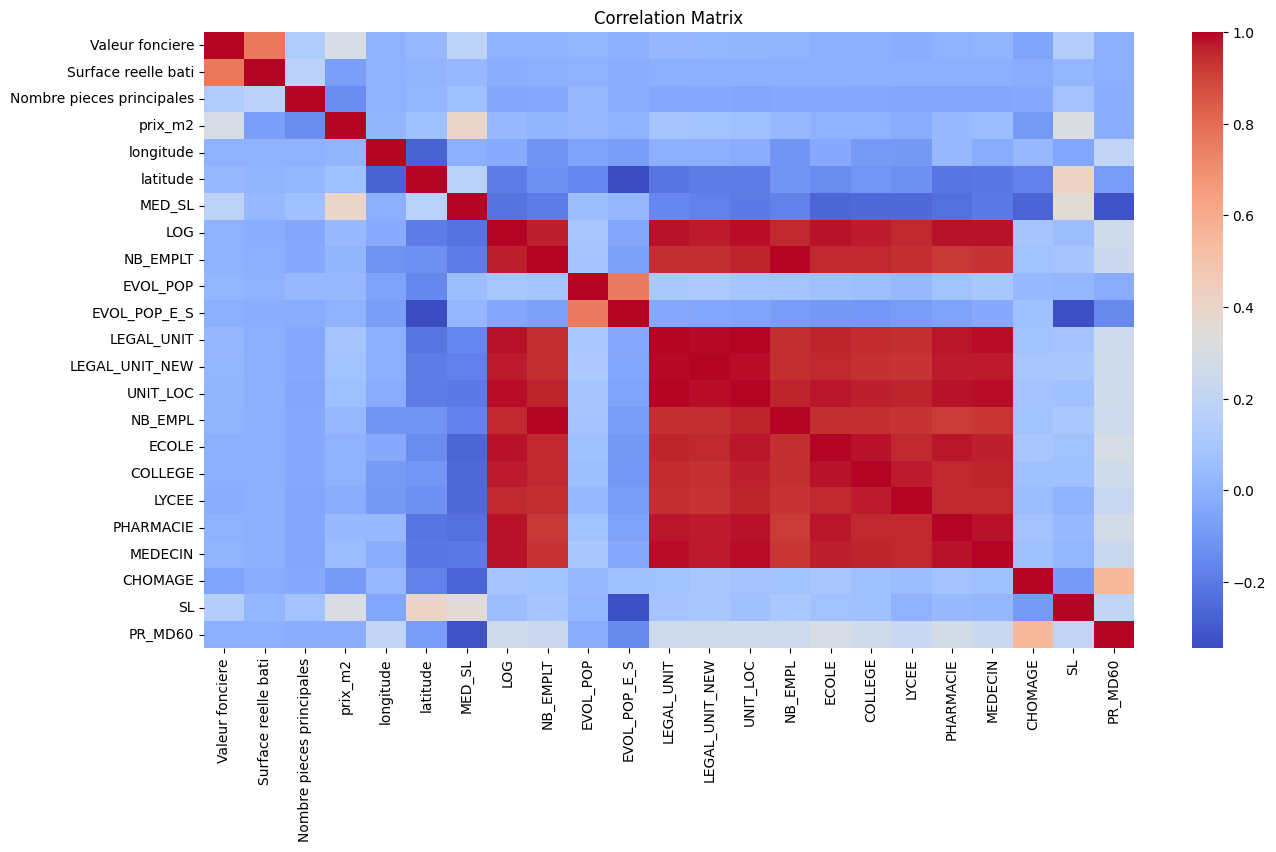

In [7]:
plt.figure(figsize=(15, 8))

sns.heatmap(
    corr,
    annot=False,
    fmt=".2f",
    cmap="coolwarm",
)

plt.title("Correlation Matrix")
plt.show()

## Corralation with target

In [8]:
target_corr = corr["prix_m2"].sort_values(ascending=False)
target_corr

prix_m2                      1.000000
MED_SL                       0.400211
SL                           0.310685
Valeur fonciere              0.294071
LEGAL_UNIT                   0.088381
LEGAL_UNIT_NEW               0.075826
latitude                     0.069435
UNIT_LOC                     0.061710
MEDECIN                      0.045469
LOG                          0.039041
PHARMACIE                    0.037729
NB_EMPL                      0.032418
EVOL_POP                     0.030540
longitude                    0.015537
NB_EMPLT                     0.014133
EVOL_POP_E_S                 0.007191
ECOLE                        0.001157
COLLEGE                     -0.002223
PR_MD60                     -0.016739
LYCEE                       -0.023265
Surface reelle bati         -0.073728
CHOMAGE                     -0.091193
Nombre pieces principales   -0.142043
Name: prix_m2, dtype: float64

## Scatterplots

### Standard of living - Correlation

In [9]:
target_corr = corr["MED_SL"].sort_values(ascending=False)
target_corr

MED_SL                       1.000000
prix_m2                      0.400211
SL                           0.352209
Valeur fonciere              0.185519
latitude                     0.162893
Nombre pieces principales    0.065634
EVOL_POP                     0.051994
Surface reelle bati          0.029153
EVOL_POP_E_S                 0.027841
longitude                   -0.003097
LEGAL_UNIT                  -0.159454
NB_EMPL                     -0.174779
LEGAL_UNIT_NEW              -0.176069
NB_EMPLT                    -0.192393
UNIT_LOC                    -0.197450
MEDECIN                     -0.199989
LOG                         -0.221705
PHARMACIE                   -0.231293
COLLEGE                     -0.250536
LYCEE                       -0.253406
ECOLE                       -0.264672
CHOMAGE                     -0.269755
PR_MD60                     -0.319784
Name: MED_SL, dtype: float64

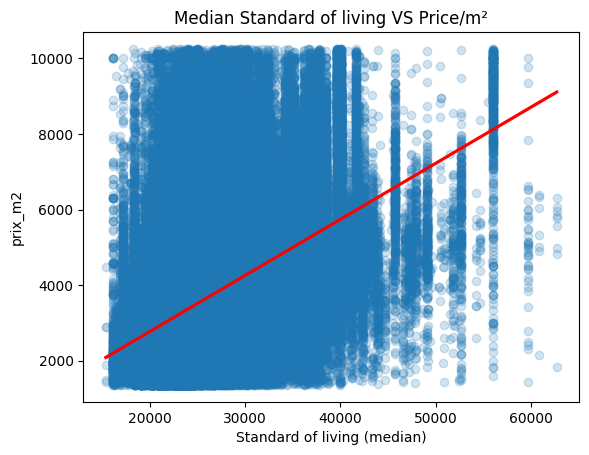

In [10]:
sns.regplot(
    data=analysis_features,
    x="MED_SL",
    y="prix_m2",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red"}
)

plt.title("Median Standard of living VS Price/m²")
plt.xlabel("Standard of living (median)")
plt.show()

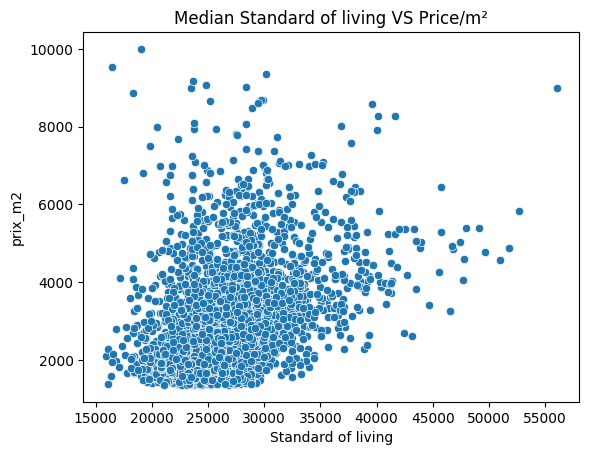

In [11]:
city_MED_SL = (
    city_analysis_features.groupby("Code postal")
    .agg({
        "prix_m2": "median",
        "MED_SL": "first"
    })
    .reset_index()
)

sns.scatterplot(
    data=city_MED_SL,
    x="MED_SL",
    y="prix_m2"
)

plt.title("Median Standard of living VS Price/m²")
plt.xlabel("Standard of living")
plt.show()

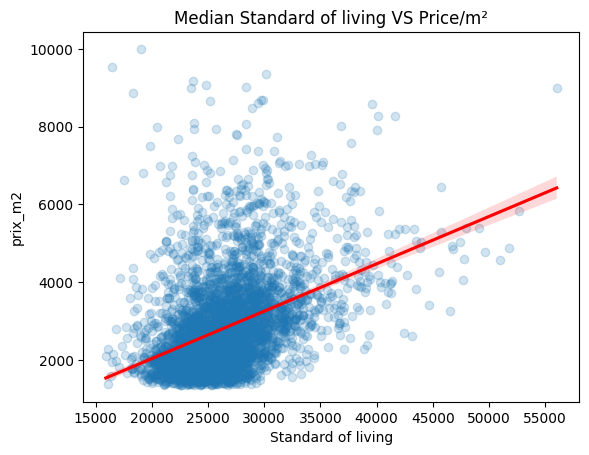

In [12]:
sns.regplot(
    data=city_MED_SL,
    x="MED_SL",
    y="prix_m2",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red"}
)


plt.title("Median Standard of living VS Price/m²")
plt.xlabel("Standard of living")
plt.show()

### Unemployment rate - Correlation

In [13]:
target_corr = corr["CHOMAGE"].sort_values(ascending=False)
target_corr

CHOMAGE                      1.000000
PR_MD60                      0.551519
ECOLE                        0.093335
LEGAL_UNIT_NEW               0.092448
LOG                          0.091363
UNIT_LOC                     0.077643
PHARMACIE                    0.077194
LEGAL_UNIT                   0.073674
NB_EMPLT                     0.071597
NB_EMPL                      0.071317
COLLEGE                      0.070338
MEDECIN                      0.061474
EVOL_POP_E_S                 0.061018
LYCEE                        0.046075
EVOL_POP                     0.038434
longitude                    0.032420
Surface reelle bati         -0.019830
Nombre pieces principales   -0.029317
Valeur fonciere             -0.053643
SL                          -0.091010
prix_m2                     -0.091193
latitude                    -0.172995
MED_SL                      -0.269755
Name: CHOMAGE, dtype: float64

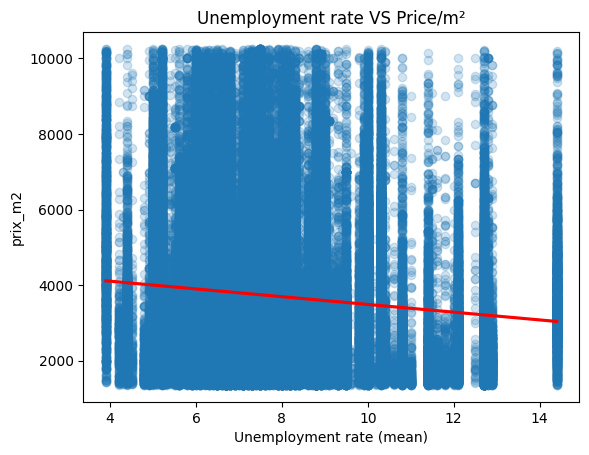

In [14]:
sns.regplot(
    data=analysis_features,
    x="CHOMAGE",
    y="prix_m2",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red"}
)

plt.title("Unemployment rate VS Price/m²")
plt.xlabel("Unemployment rate (mean)")
plt.show()

### Real estate value - Correlation

In [15]:
target_corr = corr["Valeur fonciere"].sort_values(ascending=False)
target_corr

Valeur fonciere              1.000000
Surface reelle bati          0.764714
prix_m2                      0.294071
MED_SL                       0.185519
SL                           0.144453
Nombre pieces principales    0.133338
latitude                     0.031376
LEGAL_UNIT                   0.025886
LEGAL_UNIT_NEW               0.021354
EVOL_POP                     0.019196
UNIT_LOC                     0.015747
MEDECIN                      0.010484
NB_EMPL                      0.008043
longitude                    0.007842
PHARMACIE                    0.007027
LOG                          0.003883
NB_EMPLT                     0.000594
ECOLE                       -0.004500
COLLEGE                     -0.005424
PR_MD60                     -0.006110
EVOL_POP_E_S                -0.012768
LYCEE                       -0.013503
CHOMAGE                     -0.053643
Name: Valeur fonciere, dtype: float64

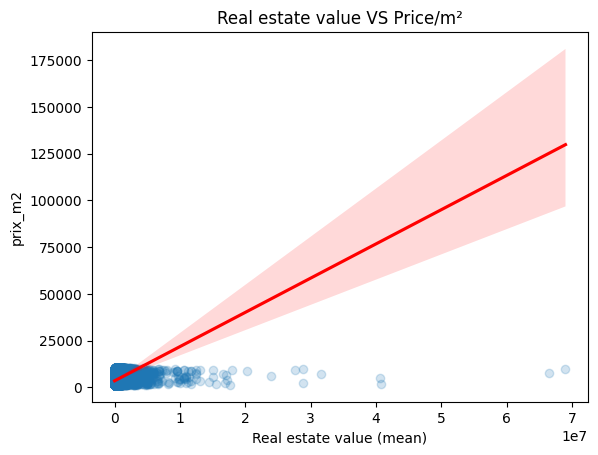

In [16]:
sns.regplot(
    data=analysis_features,
    x="Valeur fonciere",
    y="prix_m2",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red"}
)

plt.title("Real estate value VS Price/m²")
plt.xlabel("Real estate value (mean)")
plt.show()

## Feature importance (Random Forest)

### Real Estate

In [32]:
X = analysis_features[features_RF]

y = analysis_features["prix_m2"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

#### Feature importance visualization

In [33]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_,
})

importance_df = importance_df.sort_values("importance", ascending=False)

print(importance_df)

                      feature  importance
3                      MED_SL    0.331927
2                    latitude    0.215482
1                   longitude    0.098084
18                         SL    0.078892
0   Nombre pieces principales    0.066800
4                         LOG    0.044251
16                    MEDECIN    0.031687
9              LEGAL_UNIT_NEW    0.022316
6                    EVOL_POP    0.017522
7                EVOL_POP_E_S    0.014466
5                    NB_EMPLT    0.013308
12                      ECOLE    0.010280
19                    PR_MD60    0.010222
10                   UNIT_LOC    0.009929
11                    NB_EMPL    0.008578
17                    CHOMAGE    0.007993
8                  LEGAL_UNIT    0.007294
14                      LYCEE    0.003905
13                    COLLEGE    0.003831
15                  PHARMACIE    0.003236


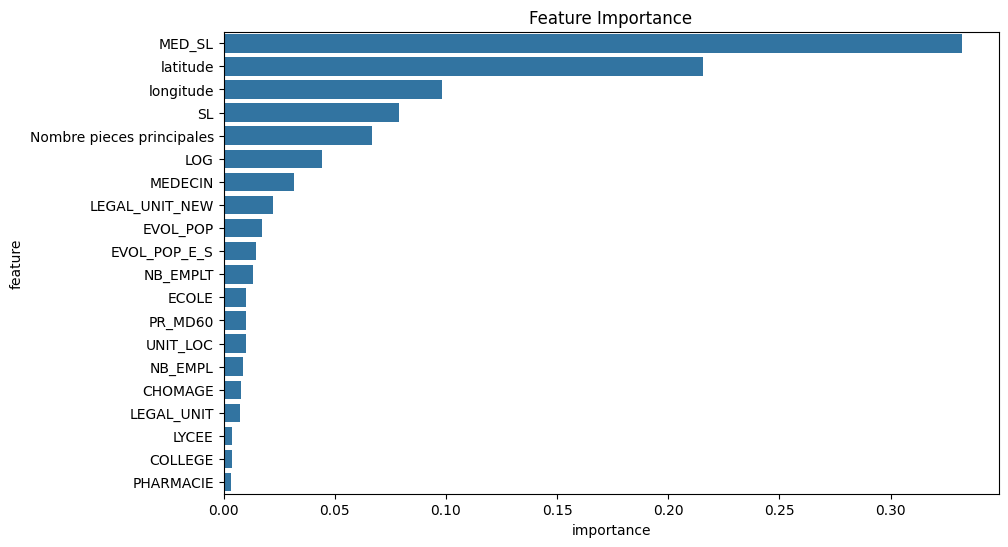

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="importance",
    y="feature"
)

plt.title("Feature Importance")
plt.show()

Interesting results:
| Feature              | Importance | Analysis                                                                                       |
|----------------------|------------|------------------------------------------------------------------------------------------------|
| MED_SL               | 0.33       | (33%) Local income is the main socio-economic factor in the real estate market                 |
| Latitude + Longitude | 0.22 + 0.1 | (22% + 10%) Differentiate: North/South, Paris, littoral, large metropolitan areas, Côte d'Azur |
| SL                   | 0.8        | (8%) High-wage areas have higher prices                                                        |
| LOG                  | 0.4        | (4.4%) Distinguishes: urban density, size of municipality, real estate tension                 |
| MEDECIN              | 0.03       | (3.1%) The attractive areas have more doctors AND high prices.                                 |

Real estate prices are mainly explained by:
1. The level of local wealth (income, wages)
2. Geography (latitude/longitude)
3. The type of property (number of rooms = Nombre pieces principales)
4. Territorial dynamism (jobs, businesses)

### Territorial

In [29]:
X = analysis_features[features_RF].drop(columns="Nombre pieces principales")

y = analysis_features["prix_m2"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

#### Feature importance visualization

In [30]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_,
})

importance_df = importance_df.sort_values("importance", ascending=False)

print(importance_df)

           feature  importance
2           MED_SL    0.365028
1         latitude    0.234252
0        longitude    0.105496
17              SL    0.084201
3              LOG    0.047636
15         MEDECIN    0.032866
8   LEGAL_UNIT_NEW    0.024885
5         EVOL_POP    0.016310
6     EVOL_POP_E_S    0.014228
4         NB_EMPLT    0.014052
11           ECOLE    0.010436
18         PR_MD60    0.010201
9         UNIT_LOC    0.008950
10         NB_EMPL    0.008190
7       LEGAL_UNIT    0.006781
16         CHOMAGE    0.006488
12         COLLEGE    0.004209
13           LYCEE    0.003230
14       PHARMACIE    0.002561
